# Lab 5 — Minimum, maximum et point selle

## Objectifs

Dans ce notebook, nous allons :

- comprendre ce que signifie $∇f(x,y)=0$ ;
- comparer visuellement un minimum, un maximum et un point selle ;
- introduire la matrice Hessienne et ses valeurs propres ;
- observer le comportement de la descente de gradient près de chaque point ;
- montrer qu'une fonction peut diminuer sans converger vers un minimum local ;
- étudier la sensibilité particulière d'un point selle.

## 1. Qu'est-ce qu'un point critique ?

Pour une fonction de deux variables, un point $(x_c,y_c)$ est critique lorsque le gradient y est nul :

$$∇f(x_c,y_c)=(0,0).$$

Cela signifie que les deux dérivées partielles sont nulles. Cependant, cette information ne permet pas encore de savoir si le point est :

- un minimum ;
- un maximum ;
- un point selle.

Le gradient donne une condition nécessaire pour de nombreux extrema, mais il ne fournit pas à lui seul leur classification.

## 2. Trois surfaces de référence

Nous étudierons trois fonctions ayant toutes un point critique en $(0,0)$.

### Minimum

$$f_{min}(x,y)=x^2+y^2$$

### Maximum

$$f_{max}(x,y)=-x^2-y^2$$

### Point selle

$$f_{selle}(x,y)=x^2-y^2$$

Les trois gradients s'annulent à l'origine, mais les surfaces n'ont pas la même courbure autour de ce point.

## 3. La matrice Hessienne

La Hessienne regroupe les dérivées partielles secondes. Elle décrit la courbure locale de la surface :

$$H_f(x,y)=[[∂^2f/∂x^2, ∂^2f/(∂x∂y)], [∂^2f/(∂y∂x), ∂^2f/∂y^2]].$$

Nous regarderons les valeurs propres de cette matrice :

- toutes positives : courbure vers le haut, donc minimum local ;
- toutes négatives : courbure vers le bas, donc maximum local ;
- signes différents : montée dans une direction et descente dans une autre, donc point selle.

## 4. Importer les bibliothèques

In [1]:
# NumPy fournit les tableaux, les grilles et le calcul des valeurs propres.
import numpy as np

# Matplotlib permet de comparer les surfaces 3D et les courbes de niveau.
import matplotlib.pyplot as plt

# Style commun à tous les graphiques du notebook.
plt.style.use("seaborn-v0_8-whitegrid")

## 5. Programmer les fonctions, les gradients et les Hessiennes

In [2]:
# Fonction possédant un minimum global à l'origine.
def fonction_minimum(x, y):
    return x**2 + y**2


# Gradient de x² + y².
def gradient_minimum(x, y):
    return np.array([2 * x, 2 * y])


# Fonction possédant un maximum global à l'origine.
def fonction_maximum(x, y):
    return -(x**2) - y**2


# Gradient de -x² - y².
def gradient_maximum(x, y):
    return np.array([-2 * x, -2 * y])


# Fonction possédant un point selle à l'origine.
def fonction_selle(x, y):
    return x**2 - y**2


# Gradient de x² - y².
def gradient_selle(x, y):
    return np.array([2 * x, -2 * y])


# Les Hessiennes sont constantes pour ces trois fonctions quadratiques.
hessienne_minimum = np.array([[2.0, 0.0], [0.0, 2.0]])
hessienne_maximum = np.array([[-2.0, 0.0], [0.0, -2.0]])
hessienne_selle = np.array([[2.0, 0.0], [0.0, -2.0]])

## 6. Vérifier et classifier le point critique

In [3]:
def classer_hessienne(hessienne):
    """Classe un point critique à partir des valeurs propres de sa Hessienne."""

    # eigvalsh est adaptée aux matrices symétriques comme les Hessiennes.
    valeurs_propres = np.linalg.eigvalsh(hessienne)

    # Toutes les courbures sont positives.
    if np.all(valeurs_propres > 0):
        classification = "minimum local"

    # Toutes les courbures sont négatives.
    elif np.all(valeurs_propres < 0):
        classification = "maximum local"

    # Présence simultanée d'une courbure positive et d'une courbure négative.
    elif np.any(valeurs_propres > 0) and np.any(valeurs_propres < 0):
        classification = "point selle"

    # Si une valeur propre vaut zéro, ce test peut ne pas suffire.
    else:
        classification = "test indéterminé"

    return valeurs_propres, classification


# Regroupement des trois cas pour éviter de répéter le code d'affichage.
cas = {
    "minimum": (gradient_minimum, hessienne_minimum),
    "maximum": (gradient_maximum, hessienne_maximum),
    "selle": (gradient_selle, hessienne_selle),
}

print(f"{'surface':>10} | {'gradient en (0,0)':>22} | {'valeurs propres':>20} | {'classification':>16}")
print("-" * 80)

for nom, (gradient_f, hessienne) in cas.items():
    # Tous les gradients sont calculés au même point.
    gradient_origine = gradient_f(0.0, 0.0)

    # Classification utilisant uniquement la courbure locale.
    valeurs_propres, classification = classer_hessienne(hessienne)

    print(f"{nom:>10} | {str(gradient_origine):>22} | {str(valeurs_propres):>20} | {classification:>16}")

   surface |      gradient en (0,0) |      valeurs propres |   classification
--------------------------------------------------------------------------------
   minimum |                [0. 0.] |              [2. 2.] |    minimum local
   maximum |              [-0. -0.] |            [-2. -2.] |    maximum local
     selle |              [ 0. -0.] |            [-2.  2.] |      point selle


Les trois gradients sont identiques au point critique : ils valent tous $(0,0)$. La différence apparaît seulement lorsque nous examinons les courbures représentées par les valeurs propres.

## 7. Comparer les trois surfaces en 3D

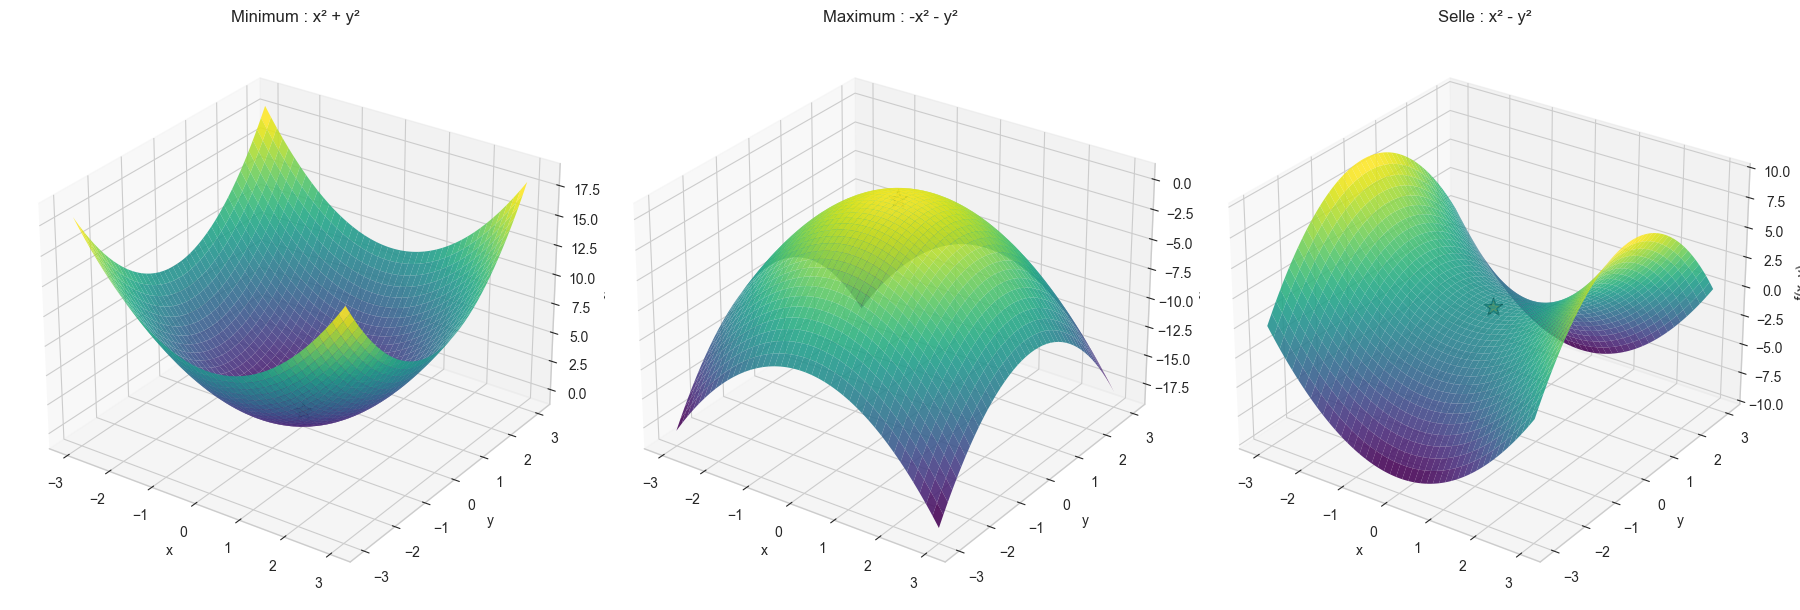

In [4]:
# Grille commune aux trois surfaces.
valeurs = np.linspace(-3, 3, 130)
X, Y = np.meshgrid(valeurs, valeurs)

# Liste des fonctions et des titres à afficher.
surfaces = [
    (fonction_minimum, "Minimum : x² + y²"),
    (fonction_maximum, "Maximum : -x² - y²"),
    (fonction_selle, "Selle : x² - y²"),
]

# Création d'une grande figure contenant trois axes 3D.
fig = plt.figure(figsize=(18, 6))

for index, (fonction, titre) in enumerate(surfaces, start=1):
    # Un sous-graphique 3D par fonction.
    ax = fig.add_subplot(1, 3, index, projection="3d")

    # Calcul puis tracé de la hauteur.
    Z = fonction(X, Y)
    ax.plot_surface(X, Y, Z, cmap="viridis", alpha=0.88, linewidth=0)

    # L'origine est le point critique commun.
    ax.scatter(0, 0, 0, marker="*", s=180, color="goldenrod", edgecolor="black", depthshade=False)

    ax.set_title(titre)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("f(x, y)")
    ax.view_init(elev=28, azim=-55)

plt.tight_layout()
plt.show()

### Lecture géométrique

- le minimum ressemble à un bol : toutes les directions remontent autour de l'origine ;
- le maximum ressemble à un bol renversé : toutes les directions descendent ;
- la selle monte selon l'axe $x$ mais descend selon l'axe $y$.

## 8. Comparer les courbes de niveau

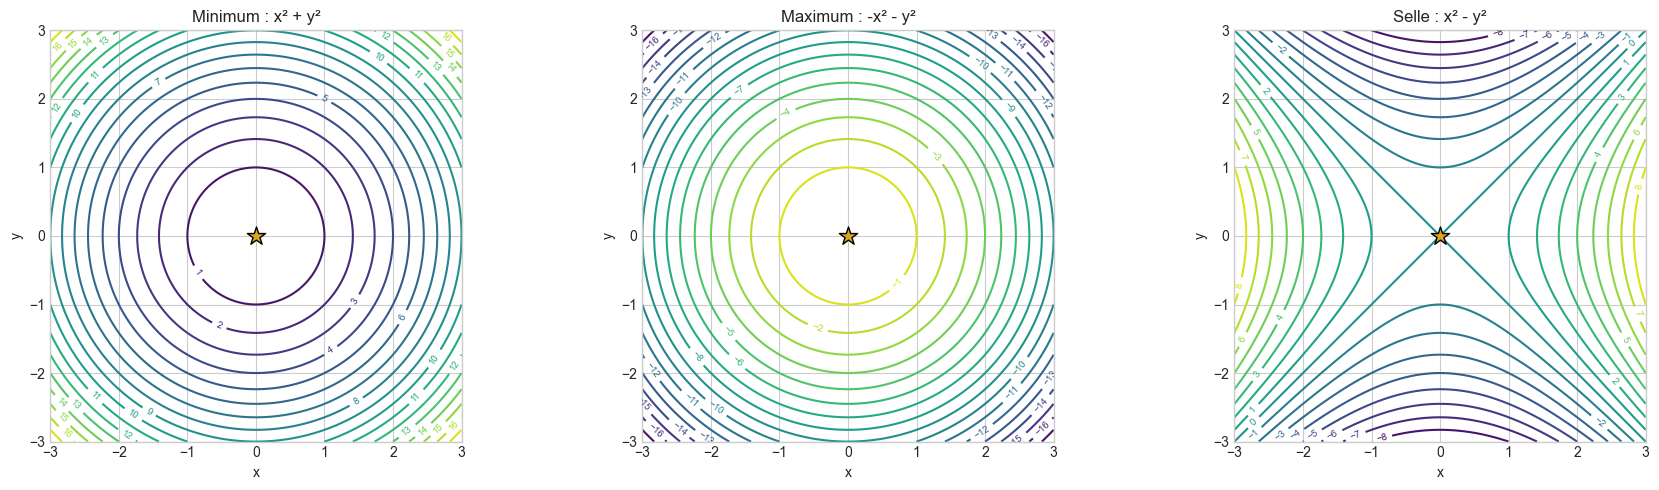

In [5]:
# Création de trois cartes vues du dessus.
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (fonction, titre) in zip(axes, surfaces):
    # Les courbes relient les points de même hauteur.
    Z = fonction(X, Y)
    niveaux = ax.contour(X, Y, Z, levels=18, cmap="viridis")
    ax.clabel(niveaux, inline=True, fontsize=7)

    # Même point critique dans les trois cas.
    ax.scatter(0, 0, marker="*", s=190, color="goldenrod", edgecolor="black", zorder=6)

    ax.set_title(titre)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_aspect("equal", adjustable="box")

plt.tight_layout()
plt.show()

## 9. Programmer la descente de gradient en deux dimensions

In [6]:
def descente_gradient_2d(gradient_f, point_depart, taux, nombre_iterations):
    """Retourne toutes les positions visitées par la descente de gradient."""

    # Conversion en tableau décimal.
    point = np.array(point_depart, dtype=float)

    # Une copie du point initial ouvre l'historique.
    historique = [point.copy()]

    for _ in range(nombre_iterations):
        # Gradient spécifique à la surface étudiée.
        vecteur_gradient = gradient_f(point[0], point[1])

        # Déplacement dans la direction opposée.
        point = point - taux * vecteur_gradient

        # Conservation de la nouvelle position.
        historique.append(point.copy())

    return np.array(historique)

## 10. Appliquer la descente aux trois surfaces

La descente de gradient cherche toujours à diminuer la fonction. Elle n'a pas pour objectif de rejoindre automatiquement n'importe quel point où le gradient vaut zéro.

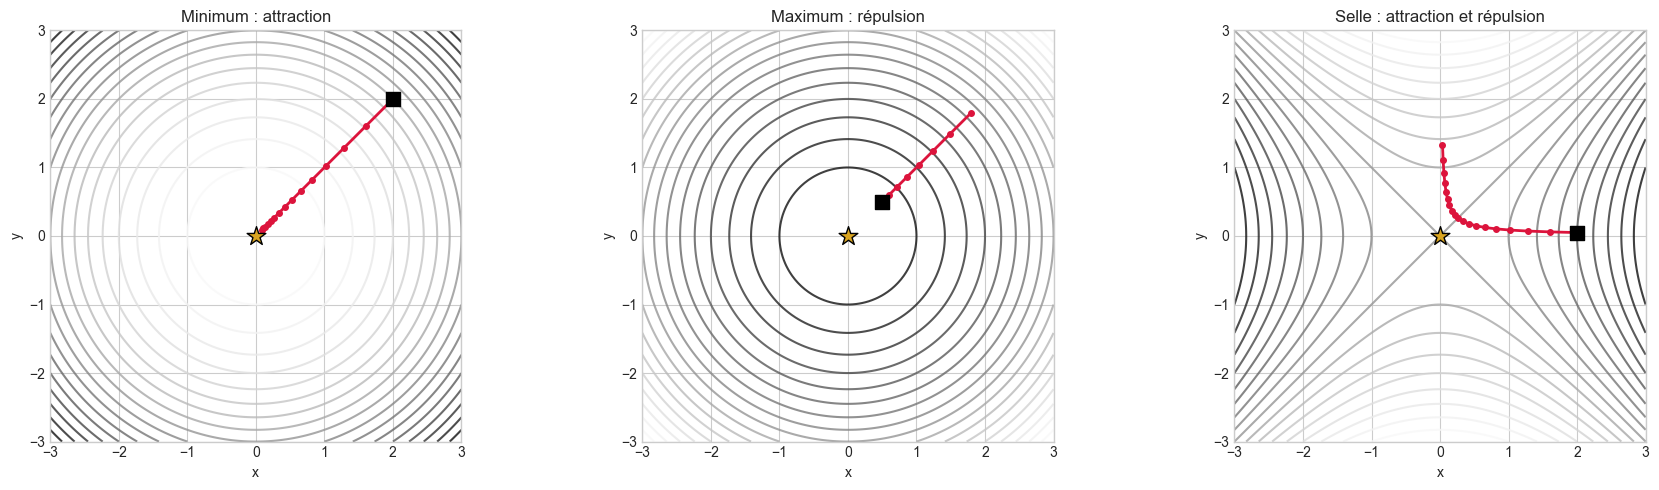

In [7]:
# Trajectoire attirée par le minimum.
trajet_minimum = descente_gradient_2d(gradient_minimum, (2.0, 2.0), taux=0.1, nombre_iterations=14)

# Trajectoire repoussée par le maximum, limitée à sept étapes pour rester visible.
trajet_maximum = descente_gradient_2d(gradient_maximum, (0.5, 0.5), taux=0.1, nombre_iterations=7)

# Près de la selle, x se rapproche de zéro mais une petite coordonnée y s'en éloigne.
trajet_selle = descente_gradient_2d(gradient_selle, (2.0, 0.05), taux=0.1, nombre_iterations=18)

experiences = [
    (fonction_minimum, trajet_minimum, "Minimum : attraction"),
    (fonction_maximum, trajet_maximum, "Maximum : répulsion"),
    (fonction_selle, trajet_selle, "Selle : attraction et répulsion"),
]

# Un graphique par expérience.
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (fonction, trajet, titre) in zip(axes, experiences):
    # Fond composé de courbes de niveau.
    Z = fonction(X, Y)
    ax.contour(X, Y, Z, levels=18, cmap="Greys", alpha=0.8)

    # Positions successives de l'algorithme.
    ax.plot(trajet[:, 0], trajet[:, 1], "o-", color="crimson", markersize=4, linewidth=2)

    # Départ, puis point critique commun.
    ax.scatter(trajet[0, 0], trajet[0, 1], marker="s", s=90, color="black", zorder=6)
    ax.scatter(0, 0, marker="*", s=200, color="goldenrod", edgecolor="black", zorder=7)

    ax.set_title(titre)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_xlim(-3, 3)
    ax.set_ylim(-3, 3)
    ax.set_aspect("equal", adjustable="box")

plt.tight_layout()
plt.show()

### Interprétation

- le minimum est attractif pour la descente ;
- le maximum est répulsif, car descendre signifie s'éloigner de son sommet ;
- la selle est attractive dans la direction $x$, mais répulsive dans la direction $y$.

## 11. Sensibilité du point selle

Si nous démarrons exactement sur l'axe $y=0$, la composante $y$ du gradient reste nulle et la trajectoire peut rejoindre la selle. Une perturbation minuscule suffit cependant à révéler la direction instable.

C:\Users\yassi\AppData\Local\Temp\ipykernel_20764\3894457768.py:37: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\yassi\Desktop\Labs\gradient\pythonProject\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


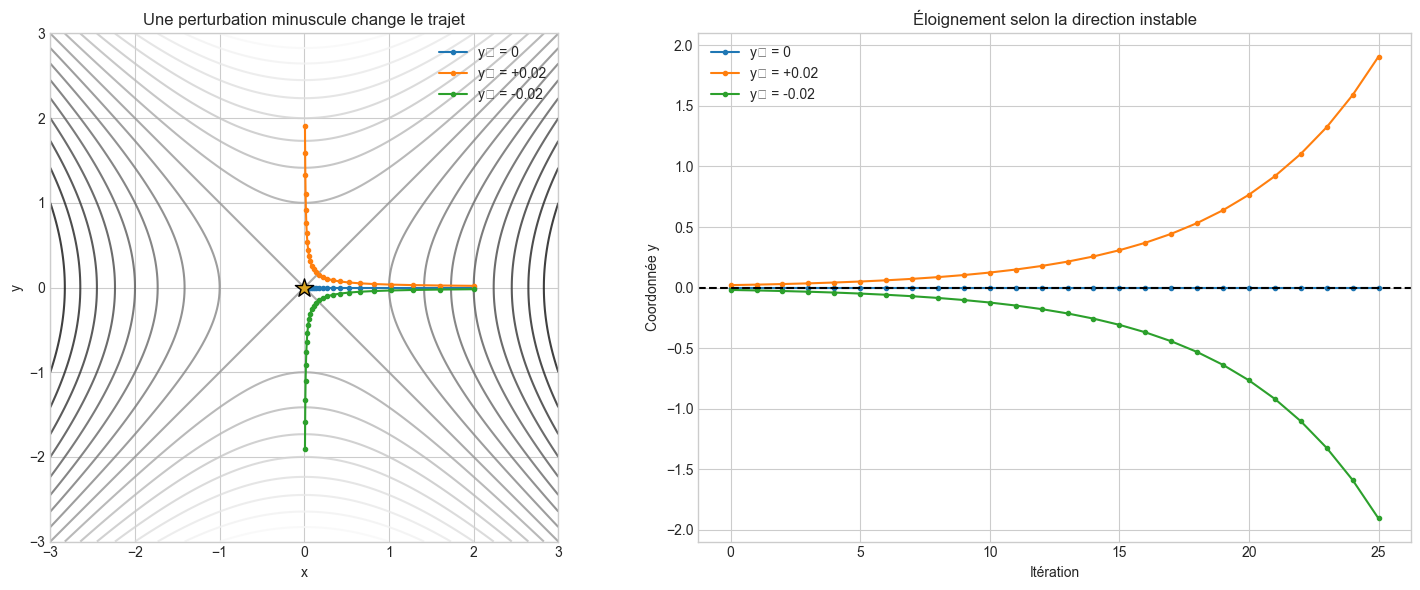

In [8]:
# Départ exactement placé sur la direction stable.
trajet_exact = descente_gradient_2d(gradient_selle, (2.0, 0.0), taux=0.1, nombre_iterations=25)

# Deux perturbations de signes opposés.
trajet_positif = descente_gradient_2d(gradient_selle, (2.0, 0.02), taux=0.1, nombre_iterations=25)
trajet_negatif = descente_gradient_2d(gradient_selle, (2.0, -0.02), taux=0.1, nombre_iterations=25)

# Création de deux vues complémentaires.
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# À gauche : trajectoires dans le plan.
Z_selle = fonction_selle(X, Y)
axes[0].contour(X, Y, Z_selle, levels=18, cmap="Greys", alpha=0.8)
axes[0].plot(trajet_exact[:, 0], trajet_exact[:, 1], "o-", markersize=3, label="y₀ = 0")
axes[0].plot(trajet_positif[:, 0], trajet_positif[:, 1], "o-", markersize=3, label="y₀ = +0.02")
axes[0].plot(trajet_negatif[:, 0], trajet_negatif[:, 1], "o-", markersize=3, label="y₀ = -0.02")
axes[0].scatter(0, 0, marker="*", s=190, color="goldenrod", edgecolor="black", zorder=7)
axes[0].set_title("Une perturbation minuscule change le trajet")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].set_xlim(-3, 3)
axes[0].set_ylim(-3, 3)
axes[0].set_aspect("equal", adjustable="box")
axes[0].legend()

# À droite : évolution de la coordonnée instable y.
iterations = np.arange(len(trajet_exact))
axes[1].plot(iterations, trajet_exact[:, 1], "o-", markersize=3, label="y₀ = 0")
axes[1].plot(iterations, trajet_positif[:, 1], "o-", markersize=3, label="y₀ = +0.02")
axes[1].plot(iterations, trajet_negatif[:, 1], "o-", markersize=3, label="y₀ = -0.02")
axes[1].axhline(0, linestyle="--", color="black")
axes[1].set_title("Éloignement selon la direction instable")
axes[1].set_xlabel("Itération")
axes[1].set_ylabel("Coordonnée y")
axes[1].legend()

plt.tight_layout()
plt.show()

Pour la selle, les mises à jour sont $x_{k+1}=0.8x_k$ et $y_{k+1}=1.2y_k$. La première coordonnée tend vers zéro, tandis que toute valeur non nulle de la seconde est amplifiée.

## 12. Une fonction qui diminue ne garantit pas un minimum

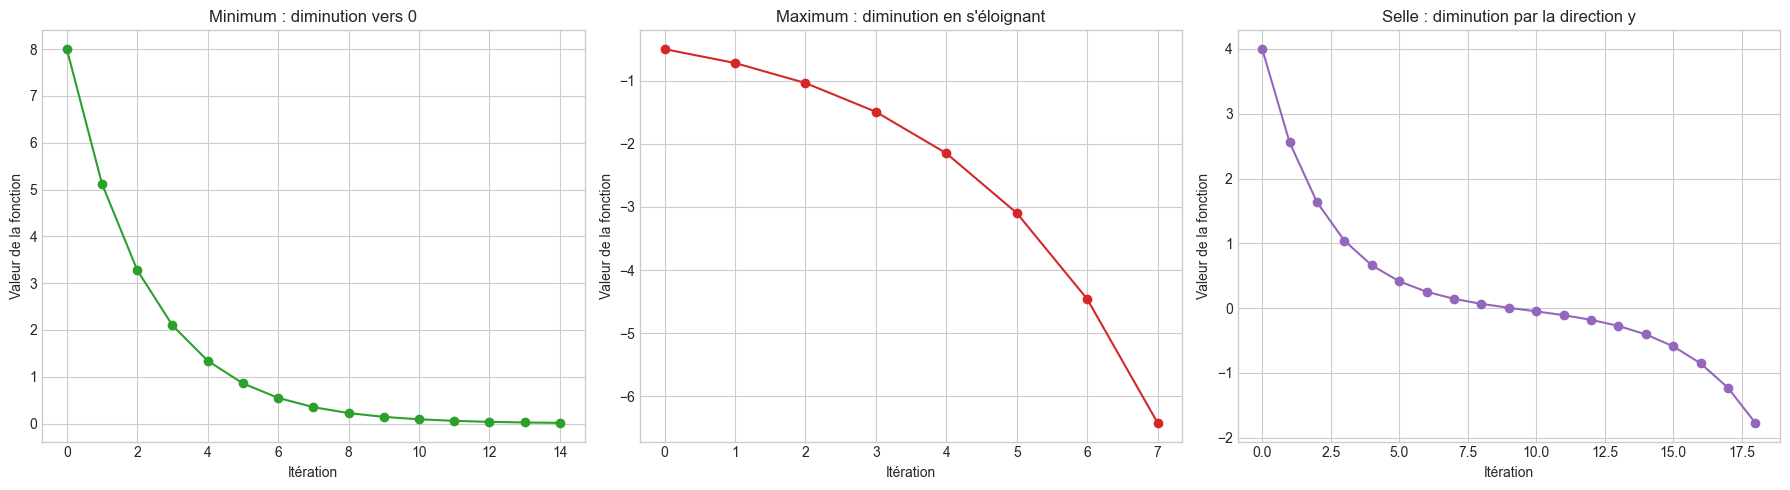

In [9]:
# Calcul de la valeur de chaque fonction le long de sa trajectoire.
valeurs_minimum = fonction_minimum(trajet_minimum[:, 0], trajet_minimum[:, 1])
valeurs_maximum = fonction_maximum(trajet_maximum[:, 0], trajet_maximum[:, 1])
valeurs_selle = fonction_selle(trajet_selle[:, 0], trajet_selle[:, 1])

# Graphique montrant que les trois fonctions diminuent.
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(valeurs_minimum, "o-", color="tab:green")
axes[0].set_title("Minimum : diminution vers 0")

axes[1].plot(valeurs_maximum, "o-", color="tab:red")
axes[1].set_title("Maximum : diminution en s'éloignant")

axes[2].plot(valeurs_selle, "o-", color="tab:purple")
axes[2].set_title("Selle : diminution par la direction y")

for ax in axes:
    ax.set_xlabel("Itération")
    ax.set_ylabel("Valeur de la fonction")

plt.tight_layout()
plt.show()

La descente remplit son objectif immédiat dans les trois cas : la valeur diminue. Pourtant, elle ne se rapproche du point critique que dans le cas du minimum. Près du maximum et dans la direction instable de la selle, diminuer la fonction exige au contraire de s'en éloigner.

## 13. Limite du test de la Hessienne

Lorsque toutes les valeurs propres sont strictement positives, strictement négatives ou de signes différents, la classification est claire. Si une valeur propre vaut zéro, le test peut être indéterminé et il faut étudier la fonction plus précisément.

Par exemple, $f(x,y)=x^4+y^4$ possède un minimum à l'origine, mais sa Hessienne y est nulle.

## 14. Ce qu'il faut retenir

1. Un gradient nul indique un point critique, pas nécessairement un minimum.
2. La Hessienne décrit la courbure locale autour de ce point.
3. Des valeurs propres positives indiquent un minimum local.
4. Des valeurs propres négatives indiquent un maximum local.
5. Des signes différents indiquent un point selle.
6. La descente est attirée par un minimum, mais repoussée par un maximum.
7. Une selle possède simultanément des directions stables et instables.
8. La diminution de $f$ à chaque étape ne prouve pas que l'algorithme rejoint un minimum local fini.

## 15. Exercice

Pour chacune des fonctions suivantes, calcule le gradient, trouve le point critique, construis la Hessienne et prédis la classification :

1. $g_1(x,y)=x^2+4y^2$ ;
2. $g_2(x,y)=-2x^2-y^2$ ;
3. $g_3(x,y)=x^2-3y^2$.

Vérifie ensuite les valeurs propres avec `np.linalg.eigvalsh`, puis représente les trois surfaces.

### Bonus

Étudie $g_4(x,y)=x^4+y^4$. Explique pourquoi la Hessienne n'arrive pas à classifier l'origine alors que le graphique montre clairement un minimum.